### 1. 로봇 이미지를 RGB 사진으로 찍음 + 로봇의 엔코더 값을 같이 받아옴
### 2. ArUco Marker로 카메라에서 마커까지의 Tvec과 Rvec를 알아냄 이후 마커가 로봇 베이스와 떨어진 정도를 측정하여 Offset으로 로봇의 베이스 좌표를 추론함
        N번 촬영된 마커 이미지는 평균내서 오차를 감소시킴 => 이미지 불안정
### 3. 카메라에서 로봇 베이스까지 T를 구하고, 이후 베이스부터 DH 파라미터를 활용하여 로봇의 각 관절과 자세(3차원)를 알아냄
### 4. 3차원 자세를 이미지에 Projection하여 시각화해봄

### 1. 3번 촬영한 영상을 평균으로 합침

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm # 진행 상황을 보여주는 라이브러리 (pip install tqdm)

# ===================================================================
# 설정
# ===================================================================

# 1. 이미지 파일이 있는 최상위 디렉토리 목록
IMAGE_BASE_DIRS = [
    # "/home/najo/NAS/DIP/datasets/meca_insertion/vla_dataset_insertion_250514",
    "/home/najo/NAS/DIP/datasets/meca_insertion/vla_dataset2_hand"
    # "/home/najo/NAS/DIP/datasets/meca_insertion/vla_dataset3_hand2",
    # 다른 데이터셋 폴더가 있다면 여기에 추가
]

# 2. 보간된 로봇 데이터 파일 경로
# 이전 단계에서 생성했거나, 동기화의 기준이 될 CSV 파일
ROBOT_DATA_PATH = "/home/najo/NAS/DIP/datasets/meca_insertion/vla_dataset2_hand/robot_data_interpolated.csv"

# 3. 동기화된 최종 결과를 저장할 파일 경로
OUTPUT_SYNC_CSV_PATH = "./synchronized_robot_camera_data.csv"

# 4. 허용할 최대 시간 차이 (초 단위)
# 이미지와 로봇 데이터의 타임스탬프 차이가 이 값보다 크면 매칭에서 제외
MAX_TIME_DIFFERENCE_THRESHOLD = 0.05  # 50ms

# ===================================================================
# 헬퍼 함수
# ===================================================================

def find_image_files(base_dirs):
    """지정된 모든 디렉토리에서 jpg, png 이미지 파일을 찾습니다."""
    image_files = []
    for base_dir in base_dirs:
        for root, _, files in os.walk(base_dir):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_files.append(os.path.join(root, f))
    return image_files

def parse_image_timestamp(image_path):
    """이미지 파일명에서 타임스탬프를 float 형태로 추출합니다."""
    try:
        # 파일명 형식: zed_SERIAL_cam_TIMESTAMP.jpg
        filename = os.path.basename(image_path)
        parts = filename.split('_')
        timestamp_str = parts[3].split('.')[0] + '.' + parts[3].split('.')[1]
        return float(timestamp_str)
    except (IndexError, ValueError):
        # 파일명 형식이 다를 경우 None 반환
        return None

# ===================================================================
# 메인 로직
# ===================================================================

def create_synchronized_dataset():
    """타임스탬프를 기준으로 이미지와 로봇 데이터를 매칭하여 새 데이터셋을 만듭니다."""
    
    # 1. 로봇 데이터 로드 및 준비
    print(f"Loading robot data from: {ROBOT_DATA_PATH}")
    if not os.path.exists(ROBOT_DATA_PATH):
        print(f"Error: Robot data file not found at {ROBOT_DATA_PATH}")
        return
        
    df_robot = pd.read_csv(ROBOT_DATA_PATH)
    robot_timestamps = df_robot['timestamp'].values # 빠른 계산을 위해 numpy 배열로 변환

    # 2. 이미지 파일 목록 생성
    print("Scanning for image files...")
    image_paths = find_image_files(IMAGE_BASE_DIRS)
    print(f"Found {len(image_paths)} total images.")

    # 3. 매칭된 데이터를 저장할 리스트
    synchronized_records = []

    # 4. 각 이미지에 대해 가장 가까운 로봇 데이터 매칭
    print("Matching images to robot data based on closest timestamp...")
    for image_path in tqdm(image_paths, desc="Processing images"):
        img_ts = parse_image_timestamp(image_path)
        if img_ts is None:
            # print(f"Could not parse timestamp from {os.path.basename(image_path)}. Skipping.")
            continue

        # 가장 가까운 타임스탬프의 인덱스 찾기
        time_diffs = np.abs(robot_timestamps - img_ts)
        closest_idx = np.argmin(time_diffs)
        min_time_diff = time_diffs[closest_idx]

        # 5. 시간 차이가 임계값 이내인지 확인
        if min_time_diff < MAX_TIME_DIFFERENCE_THRESHOLD:
            # 매칭 성공: 로봇 데이터 행 가져오기
            matching_robot_row = df_robot.iloc[closest_idx]
            
            # 레코드 생성
            record = {
                'image_path': image_path,
                'image_timestamp': img_ts,
                'robot_timestamp': matching_robot_row['timestamp'],
                'time_difference_s': min_time_diff
            }
            # 로봇 데이터의 모든 열을 레코드에 추가
            record.update(matching_robot_row.to_dict())
            
            synchronized_records.append(record)

    # 6. 최종 결과를 DataFrame으로 변환하고 저장
    if not synchronized_records:
        print("No valid matches found. No output file was created.")
        return
        
    df_sync = pd.DataFrame(synchronized_records)
    df_sync.sort_values('image_timestamp', inplace=True)
    
    df_sync.to_csv(OUTPUT_SYNC_CSV_PATH, index=False)
    
    print("\n--- Synchronization Complete ---")
    print(f"✅ Total {len(df_sync)} image-robot pairs were successfully synchronized.")
    print(f"✅ Result saved to: {OUTPUT_SYNC_CSV_PATH}")
    print("\n--- Sample of the synchronized data ---")
    print(df_sync[['image_path', 'time_difference_s', 'j1', 'j2', 'j3']].head())


if __name__ == '__main__':
    create_synchronized_dataset()

Loading robot data from: /home/najo/NAS/DIP/datasets/meca_insertion/vla_dataset2_hand/robot_data_interpolated.csv
Error: Robot data file not found at /home/najo/NAS/DIP/datasets/meca_insertion/vla_dataset2_hand/robot_data_interpolated.csv


[front] 저장 완료: front_41182735_leftcam_calib.json (distortion: [-0.005643106304680097, -0.04613633865985787, 0.00013427180750958065, 0.000311206091784389, 0.014788022640489918])
[front] 저장 완료: front_41182735_rightcam_calib.json (distortion: [-0.011644211970573087, -0.03446171529477812, -0.00025158205901685437, -1.601647386337792e-05, 0.009449363842105223])
[right] 저장 완료: right_49429257_leftcam_calib.json (distortion: [-0.004324792836863234, -0.044924273051576244, -0.00015804802069500418, 8.446305090471108e-05, 0.014128446052889002])
[right] 저장 완료: right_49429257_rightcam_calib.json (distortion: [-0.004010291097564468, -0.04379502094552287, -0.00021885868880579663, 0.000343442064376711, 0.013218838686316696])
[left] 저장 완료: left_44377151_leftcam_calib.json (distortion: [-0.0017388454017429765, -0.05135136385205364, -4.901526708441068e-05, 7.529832735358121e-05, 0.018002525767767445])
[left] 저장 완료: left_44377151_rightcam_calib.json (distortion: [-0.0005965345717048424, -0.05041587810673526

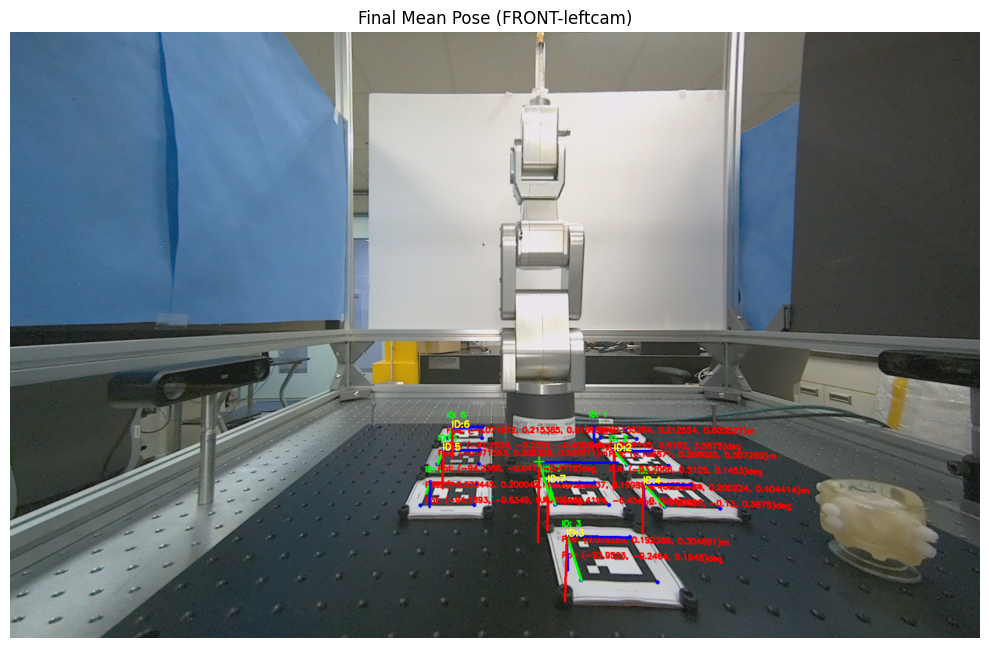

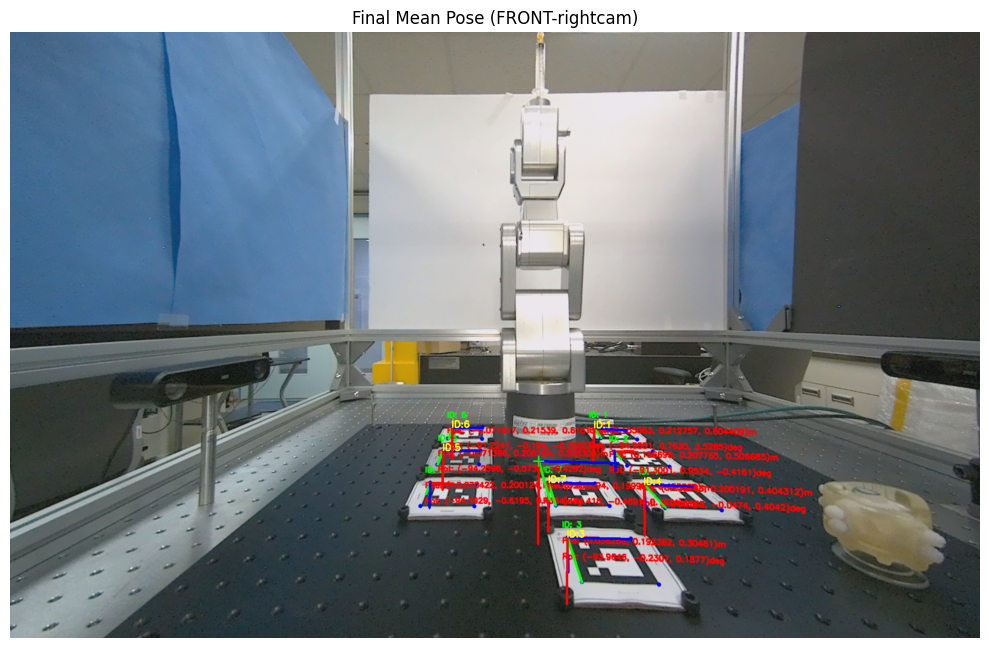

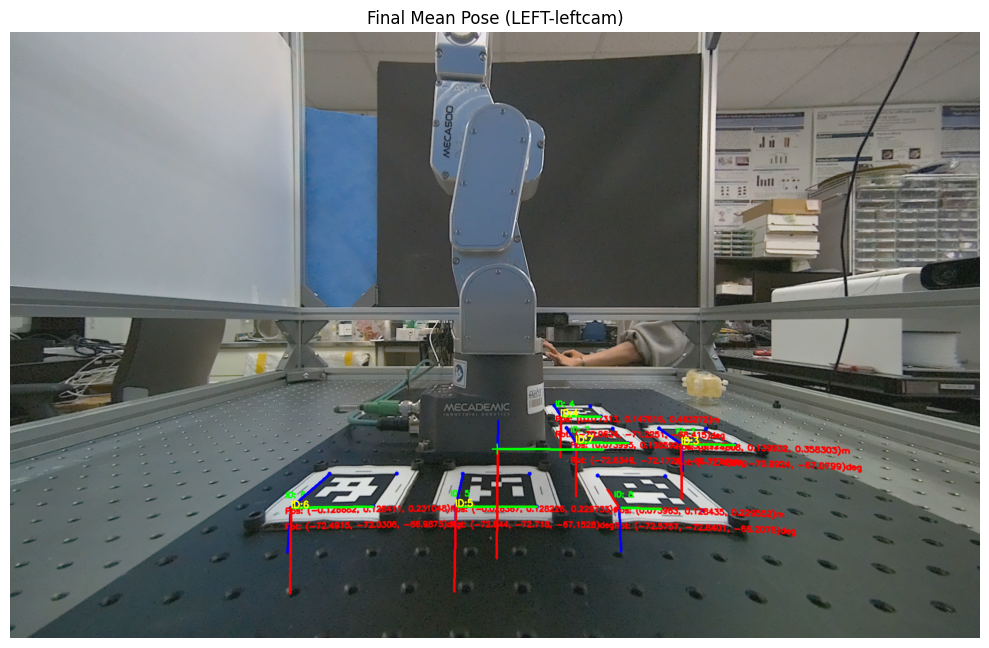

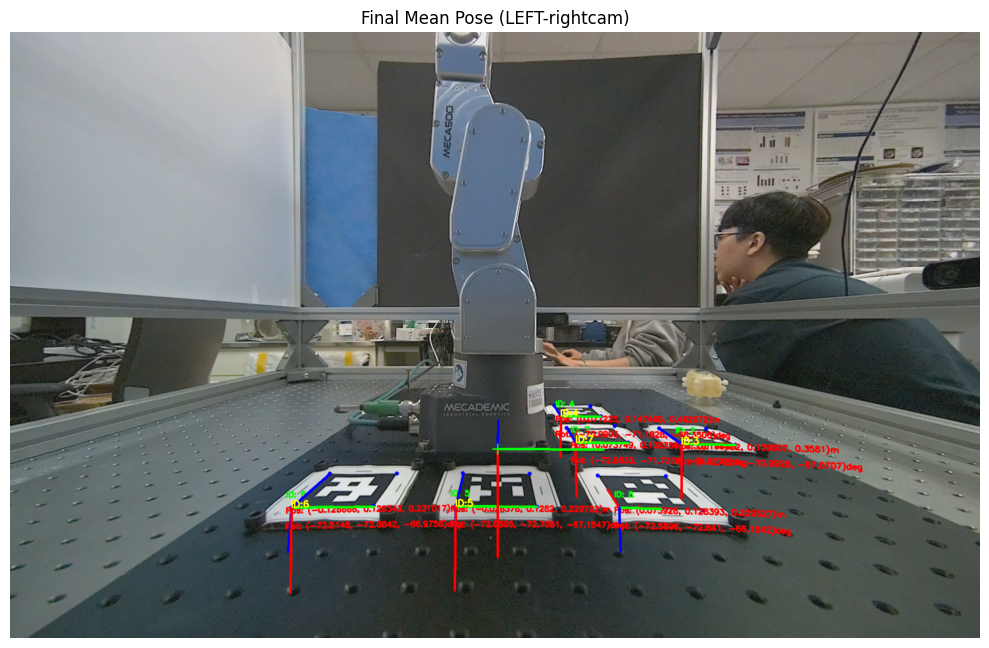

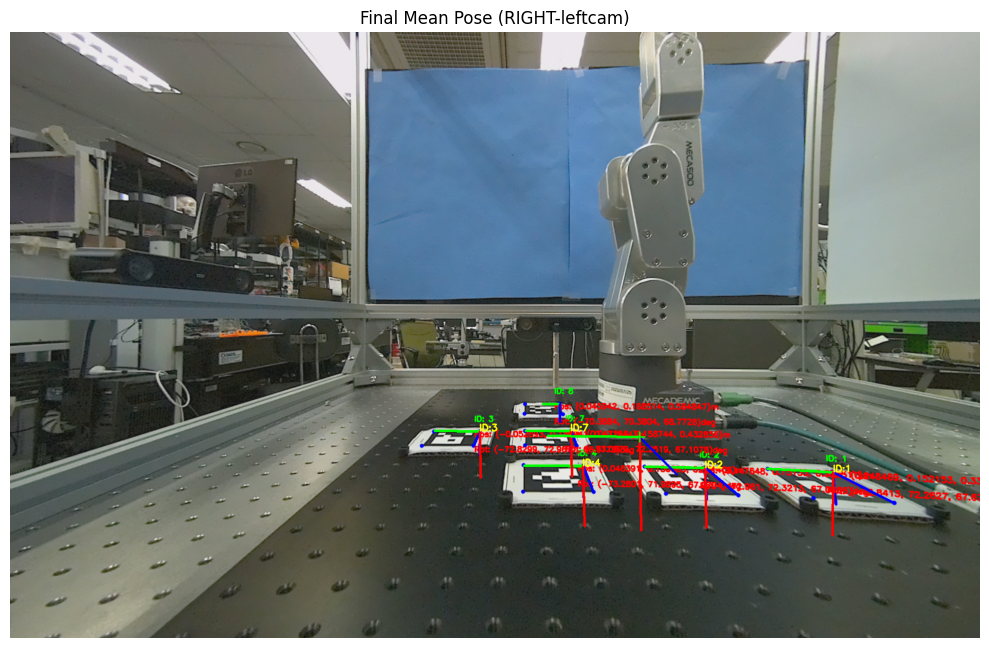

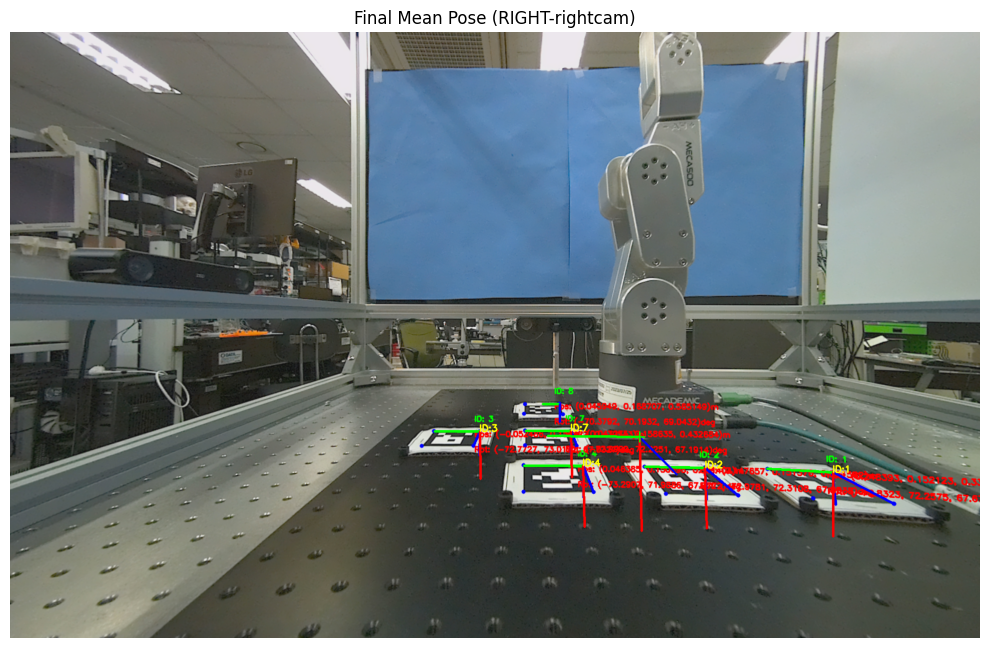

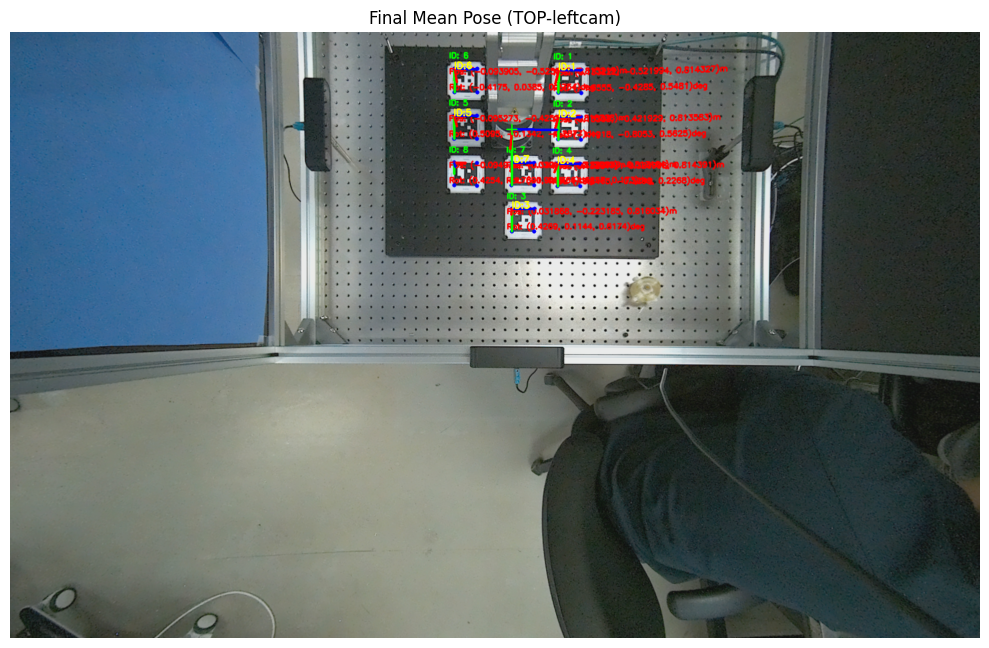

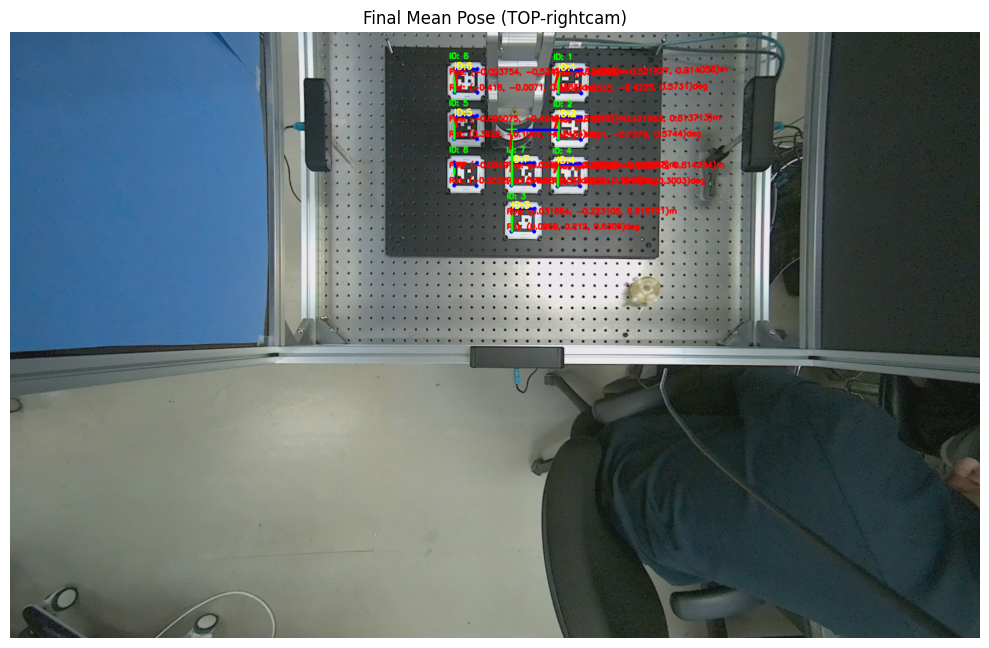


--- All stages complete. Final summary saved to: ./Meca_insertion//aruco_final_summary.json ---
    view       cam    mean_x    mean_y    mean_z     std_x     std_y  \
0  front   leftcam  0.046345  0.190714  0.470093  0.000801  0.004183   
1  front  rightcam  0.060002  0.210981  0.470187  0.002164  0.004436   
2   left   leftcam -0.004331  0.138771  0.355153  0.002726  0.003414   
3   left  rightcam  0.000063  0.136197  0.354346  0.002424  0.003366   
4  right   leftcam  0.151745  0.135974  0.407595  0.002314  0.002900   
5  right  rightcam  0.150504  0.141653  0.407369  0.002174  0.003208   
6    top   leftcam  0.028926 -0.410241  0.826029  0.001331  0.001593   
7    top  rightcam  0.031638 -0.405052  0.827947  0.001216  0.001420   

      std_z  proj_x  proj_y  rvec_x_deg  rvec_y_deg  rvec_z_deg  
0  0.008014    1047     851  -91.542656   -1.497092    0.022929  
1  0.004799    1046     850  -93.990679    0.215355    1.457610  
2  0.004742     964     826  -70.852633  -71.659073  -67

In [2]:
import os
import glob
import json
import cv2
import numpy as np
from collections import defaultdict
from scipy.spatial.transform import Rotation as R
import pandas as pd
import matplotlib.pyplot as plt

# =================================================================================
# 통합 설정
# =================================================================================

# --- 1단계 설정: Raw 데이터 경로 ---
RAW_DATA_DIRS = [
    "./Meca_insertion/Meca_ArUco/ArUco_cap_250514",
    "./Meca_insertion/Meca_ArUco/ArUco_cap2_250514",
    "./Meca_insertion/Meca_ArUco/ArUco_cap3_250514"
]

# --- 2단계 설정: Pose 재계산용 ---
MARKER_REAL_SIZE_M = 0.05  # ★★★ 중요: 마커의 실제 한 변 길이 (미터)

# --- 3단계 설정: 시각화 및 최종 오프셋 ---
CALIB_DIR = "./Meca_insertion/Meca_calib_cam_from_conf"
IMAGE_DIR = "./Meca_insertion/Meca_ArUco/ArUco_cap_250514" # 시각화에 사용할 대표 이미지 경로
FINAL_SUMMARY_OUTPUT_PATH = "./Meca_insertion//aruco_final_summary.json"

camera_serials = {"front":41182735, "right":49429257, "left":44377151, "top":49045152}
views = ['front', 'left', 'right', 'top']
cams = ['leftcam', 'rightcam']

# 최종 객체 자세 추정을 위한 마커 오프셋
marker_offsets = {
    "front": { "1": np.array([-0.100, 0.125, 0.0065]), "2": np.array([-0.100, 0.025, 0.0065]), "3": np.array([0, -0.175, 0.0065]), "4": np.array([-0.100, -0.075, 0.0065]), "5": np.array([0.125, 0.025, 0.0065]), "6": np.array([0.125, 0.125, 0.0065]), "7": np.array([0, -0.075, 0.0065]), "8": np.array([0.125, -0.075, 0.0065]) },
    "left": { "3": np.array([0, -0.175, 0.0065]), "4": np.array([-0.100, -0.075, 0.0065]), "5": np.array([0.125, 0.025, 0.0065]), "6": np.array([0.125, 0.125, 0.0065]), "7": np.array([0.000, -0.075, 0.0065]), "8": np.array([0.125, -0.075, 0.0065]) },
    "right": { "1": np.array([-0.100, 0.125, 0.0065]), "2": np.array([-0.100, 0.025, 0.0065]), "3": np.array([0.000, -0.175, 0.0065]), "4": np.array([-0.100, -0.075, 0.0065]), "7": np.array([0.000, -0.075, 0.0065]), "8": np.array([0.125, -0.075, 0.0065]) },
    "top": { "1": np.array([-0.100, 0.125, 0.0065]), "2": np.array([-0.100, 0.025, 0.0065]), "3": np.array([0, -0.175, 0.0065]), "4": np.array([-0.100, -0.075, 0.0065]), "5": np.array([0.125, 0.025, 0.0065]), "6": np.array([0.125, 0.125, 0.0065]), "7": np.array([0, -0.075, 0.0065]), "8": np.array([0.125, -0.075, 0.0065]) },
}
import os
import json
import configparser

# 시리얼 ↔ 위치 매핑
camera_list = {
    41182735: "front", # front # marker 1, 2, 4, 5, 6
    49429257: "right", # right # marker 2, 4, 7, 8
    44377151: "left", # left  # marker 3, 5, 7, 8
    49045152: "top"  # top   # marker 1, 2, 4, 6, 7, 8
}


zed_conf_dir = "./All_camera_conf"
output_dir = "./Meca_insertion/Meca_calib_cam_from_conf"
os.makedirs(output_dir, exist_ok=True)
def load_fhd_calibration(conf_path, side):
    config = configparser.ConfigParser()

    # UTF-8 BOM 제거하여 파일 읽기
    with open(conf_path, "r", encoding="utf-8-sig") as f:
        config.read_file(f)

    section = f"{side.upper()}_CAM_FHD1200"
    adv_section = f"{side.upper()}_DISTO"

    cam = config[section]

    fx = float(cam["fx"])
    fy = float(cam["fy"])
    cx = float(cam["cx"])
    cy = float(cam["cy"])
    k1 = float(cam["k1"])
    k2 = float(cam["k2"])
    p1 = float(cam["p1"])
    p2 = float(cam["p2"])
    k3 = float(cam["k3"])

    camera_matrix = [
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0]
    ]
    distortion_coeffs = [k1, k2, p1, p2, k3]

    adv_dist = {}
    if adv_section in config:
        adv = config[adv_section]
        for key in adv:
            adv_dist[key] = float(adv[key])

    return camera_matrix, distortion_coeffs, adv_dist


# 전체 처리
for serial, position in camera_list.items():
    conf_path = os.path.join(zed_conf_dir, f"SN{serial}.conf")
    
    if not os.path.exists(conf_path):
        print(f"[{position}] 설정 파일 없음: {conf_path}")
        continue

    for side, side_name in [("LEFT", "leftcam"), ("RIGHT", "rightcam")]:
        try:
            cam_matrix, dist_coeffs, adv_dist = load_fhd_calibration(conf_path, side)

            data = {
                "camera_matrix": cam_matrix,
                "distortion_coeffs": dist_coeffs,
                "advanced_distortion": adv_dist
            }

            filename = f"{position}_{serial}_{side_name}_calib.json"
            with open(os.path.join(output_dir, filename), "w") as f:
                json.dump(data, f, indent=4)
            print(f"[{position}] 저장 완료: {filename} (distortion: {dist_coeffs})")

        except Exception as e:
            print(f"[{position}] {side_name} 처리 중 오류: {e}")
            
# =================================================================================
# 헬퍼 함수
# =================================================================================
def parse_filename(filename):
    parts = filename.split('_')
    view = parts[0]
    cam = parts[2]
    return view, cam

def average_quaternion(quaternions):
    if len(quaternions) == 0: return np.array([0,0,0,1])
    return R.from_quat(quaternions).mean().as_quat()

def average_position(positions):
    if len(positions) == 0: return np.array([0,0,0])
    return np.mean(positions, axis=0)

def remove_outliers(positions, quaternions, pos_thresh=0.001, rot_thresh_deg=3):
    if len(positions) < 2: return positions, quaternions, np.ones(len(positions), dtype=bool)
    avg_pos = average_position(positions)
    avg_quat = average_quaternion(quaternions)
    pos_dists = np.linalg.norm(positions - avg_pos, axis=1)
    pos_mask = pos_dists < pos_thresh
    avg_rot = R.from_quat(avg_quat)
    angular_distances = np.array([(avg_rot.inv() * R.from_quat(q)).magnitude() for q in quaternions]) * 180 / np.pi
    rot_mask = angular_distances < rot_thresh_deg
    valid_mask = pos_mask & rot_mask
    return positions[valid_mask], quaternions[valid_mask], valid_mask

# =================================================================================
# 메인 로직
# =================================================================================

# --- 1단계: 이상치 제거 및 평균 계산 ---
print("--- STAGE 1: Averaging Raw Data and Removing Outliers ---")
raw_data = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
for base_dir in RAW_DATA_DIRS:
    for fname in os.listdir(base_dir):
        if not fname.endswith('.json'): continue
        view, cam = parse_filename(fname)
        with open(os.path.join(base_dir, fname), 'r') as f:
            content = json.load(f)
            for marker_id, marker_data in content.items():
                if "corners_pixel" in marker_data:
                    raw_data[view][cam][marker_id].append(marker_data)

corrected_data_stage1 = defaultdict(lambda: defaultdict(dict))
for view in raw_data:
    for cam in raw_data[view]:
        for marker_id, entries in raw_data[view][cam].items():
            if len(entries) < 2:
                corrected_data_stage1[view][cam][marker_id] = entries[0]
                continue
            
            positions = np.array([[m['position_m']['x'], m['position_m']['y'], m['position_m']['z']] for m in entries])
            quaternions = np.array([[m['rotation_quat']['x'], m['rotation_quat']['y'], m['rotation_quat']['z'], m['rotation_quat']['w']] for m in entries])
            corners = np.array([m['corners_pixel'] for m in entries], dtype=np.float32)

            positions_filtered, quats_filtered, mask = remove_outliers(positions, quaternions)
            corners_filtered = corners[mask]

            if len(positions_filtered) == 0 or len(positions_filtered) < len(entries) / 2:
                print(f"Marker {marker_id} in {view}_{cam} is excluded.")
                continue

            avg_pos = average_position(positions_filtered)
            avg_quat = average_quaternion(quats_filtered)
            avg_corners = np.mean(corners_filtered, axis=0)

            corrected_data_stage1[view][cam][marker_id] = {
                "position_m": {"x": float(avg_pos[0]), "y": float(avg_pos[1]), "z": float(avg_pos[2])},
                "rotation_quat": {"x": float(avg_quat[0]), "y": float(avg_quat[1]), "z": float(avg_quat[2]), "w": float(avg_quat[3])},
                "corners_pixel": avg_corners.tolist()
            }
print("--- STAGE 1 Complete ---\n")


# --- 2단계: Top-Left 기준 Pose 재계산 ---
print("--- STAGE 2: Recalculating Pose from Top-Left Corner ---")
marker_3d_points = np.array([
    [0, 0, 0], [MARKER_REAL_SIZE_M, 0, 0], [MARKER_REAL_SIZE_M, MARKER_REAL_SIZE_M, 0], [0, MARKER_REAL_SIZE_M, 0]
], dtype=np.float32)

recalculated_data_stage2 = defaultdict(lambda: defaultdict(dict))
for view in corrected_data_stage1:
    for cam in corrected_data_stage1[view]:
        serial = camera_serials.get(view)
        if not serial: continue
        calib_path = os.path.join(CALIB_DIR, f"{view}_{serial}_{cam}_calib.json")
        if not os.path.exists(calib_path): continue
        
        with open(calib_path) as f: calib_data = json.load(f)
        camera_matrix = np.array(calib_data["camera_matrix"], dtype=np.float64)
        dist_coeffs = np.array(calib_data["distortion_coeffs"], dtype=np.float64)

        for marker_id, data in corrected_data_stage1[view][cam].items():
            corners_2d = np.array(data["corners_pixel"], dtype=np.float32)
            ret, rvec, tvec = cv2.solvePnP(marker_3d_points, corners_2d, camera_matrix, dist_coeffs)
            if not ret: continue
            
            rvec, tvec = cv2.solvePnPRefineLM(marker_3d_points, corners_2d, camera_matrix, dist_coeffs, rvec, tvec)
            new_position = {"x": tvec[0][0], "y": tvec[1][0], "z": tvec[2][0]}
            rotation = R.from_rotvec(rvec.flatten())
            quat = rotation.as_quat()
            new_rotation = {"x": quat[0], "y": quat[1], "z": quat[2], "w": quat[3]}
            
            recalculated_data_stage2[view][cam][marker_id] = {
                "position_m": new_position, "rotation_quat": new_rotation, "corners_pixel": data["corners_pixel"]
            }
print("--- STAGE 2 Complete ---\n")


# --- 3단계: 최종 오프셋 적용, 시각화 및 요약 ---
print("--- STAGE 3: Applying Final Offsets, Visualizing, and Summarizing ---")
final_summary = []
font = cv2.FONT_HERSHEY_SIMPLEX
for view in views:
    for cam in cams:
        poses = recalculated_data_stage2.get(view, {}).get(cam)
        if not poses: continue
        
        serial = camera_serials.get(view)
        calib_path = os.path.join(CALIB_DIR, f"{view}_{serial}_{cam}_calib.json")
        img_files = glob.glob(os.path.join(IMAGE_DIR, f"{view}_*_{cam}_*.png"))
        if not os.path.exists(calib_path) or not img_files: continue

        with open(calib_path) as f: calib = json.load(f)
        K = np.array(calib["camera_matrix"], dtype=np.float64)
        dist = np.array(calib["distortion_coeffs"], dtype=np.float64)
        
        img = cv2.imread(img_files[0])
        undistorted_img = cv2.undistort(img, K, dist, None, K)
        img_vis = cv2.cvtColor(undistorted_img, cv2.COLOR_BGR2RGB)

        offset_applied_positions = []
        all_quaternions = []
        valid_marker_ids = []

        for mid, offset in marker_offsets[view].items():
            if mid not in poses or mid == "8": continue
            
            p = poses[mid]
            tvec = np.array([p["position_m"]["x"], p["position_m"]["y"], p["position_m"]["z"]])
            quat = np.array([p["rotation_quat"][k] for k in ("x", "y", "z", "w")])
            Rm = R.from_quat(quat).as_matrix()
            
            tvec_with_offset = tvec + Rm.dot(offset)
            offset_applied_positions.append(tvec_with_offset)
            all_quaternions.append(quat)
            valid_marker_ids.append(mid)
            
            rvec = R.from_quat(quat).as_rotvec()
            cv2.drawFrameAxes(img_vis, K, None, rvec, tvec.reshape(3, 1), 0.05)
            marker_pos_2d, _ = cv2.projectPoints(tvec.reshape(1, 3), np.zeros((3, 1)), np.zeros((3, 1)), K, None)
            cv2.putText(img_vis, f"ID:{mid}", tuple(marker_pos_2d.ravel().astype(int)), font, 0.6, (255, 255, 0), 2)

        if not offset_applied_positions: continue
        
        mean_offset_pos = np.mean(offset_applied_positions, axis=0)
        std_offset_pos = np.std(offset_applied_positions, axis=0)
        
        ref_mid = min(valid_marker_ids, key=lambda m: np.linalg.norm(marker_offsets[view][m]))
        ref_idx = valid_marker_ids.index(ref_mid)
        ref_quat = all_quaternions[ref_idx]
        R_ref = R.from_quat(ref_quat).as_matrix()
        R_all_relative = [R_ref.T @ R.from_quat(q).as_matrix() for q in all_quaternions]
        R_mean_relative = R.from_matrix(R_all_relative).mean()
        R_mean_global = R_ref @ R_mean_relative.as_matrix()
        mean_rvec = R.from_matrix(R_mean_global).as_rotvec()
        
        cv2.drawFrameAxes(img_vis, K, None, mean_rvec, mean_offset_pos, 0.1, thickness=4)
        mean_proj, _ = cv2.projectPoints(mean_offset_pos, np.zeros((3,1)), np.zeros((3,1)), K, None)
        xm, ym = mean_proj.ravel().astype(int)
        cv2.drawMarker(img_vis, (xm, ym), (0, 255, 0), cv2.MARKER_CROSS, 20, 2)

        deg_rvec = np.rad2deg(mean_rvec)
        final_summary.append({
            "view": view, "cam": cam, 
            "mean_x": mean_offset_pos[0], "mean_y": mean_offset_pos[1], "mean_z": mean_offset_pos[2],
            "std_x": std_offset_pos[0], "std_y": std_offset_pos[1], "std_z": std_offset_pos[2],
            "proj_x": xm, "proj_y": ym,
            "rvec_x_deg": deg_rvec[0], "rvec_y_deg": deg_rvec[1], "rvec_z_deg": deg_rvec[2]
        })

        plt.figure(figsize=(10, 8))
        plt.imshow(img_vis)
        plt.title(f"Final Mean Pose ({view.upper()}-{cam})")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# --- 최종 요약 파일 저장 ---
df = pd.DataFrame(final_summary)
df.to_json(FINAL_SUMMARY_OUTPUT_PATH, orient="records", indent=4)

print(f"\n--- All stages complete. Final summary saved to: {FINAL_SUMMARY_OUTPUT_PATH} ---")
print(df)

In [3]:
import os
import json
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm # tqdm for progress bar in loop

# ===================================================================
# 1. 설정 (변경 없음)
# ===================================================================

# 동기화된 데이터 파일 경로 (첫 번째 스크립트의 출력)
SYNC_CSV_PATH = "./synchronized_robot_camera_data.csv" 

# ArUco 및 보정 데이터 경로 (이전과 동일)
ARUCO_PATH = './aruco_final_summary.json'
CALIB_DIR = "./Calib_cam_from_conf"

# 결과 이미지를 저장할 디렉토리 (모든 데이터를 처리할 경우 사용)
OUTPUT_VIS_DIR = "./synchronized_visualization"
os.makedirs(OUTPUT_VIS_DIR, exist_ok=True)


# ===================================================================
# 2. 데이터 로딩 함수 (변경 없음)
# ===================================================================
def load_data_from_sync_row(sync_row, aruco_summary_path, calib_dir):
    """
    동기화된 데이터프레임의 한 행(row)을 기반으로 필요한 모든 데이터를 로드.
    타임스탬프 검색 과정이 필요 없어짐.
    """
    image_path = sync_row['image_path']
    
    # 이미지 경로에서 카메라 정보 파싱
    image_name = os.path.basename(image_path)
    parts = image_name.split('_')
    serial_str = parts[1]
    serial_to_view = {"41182735": "front", "44377151": "left", "49429257": "right", "49045152": "top"}
    view = serial_to_view.get(serial_str)
    cam = parts[2] + "cam"
    if not view: raise ValueError(f"Unknown serial number: {serial_str}")
    
    # ArUco 결과 로드
    with open(aruco_summary_path, 'r') as f:
        aruco_results_all = json.load(f)
    aruco_result = next((item for item in aruco_results_all if item['view'] == view and item['cam'] == cam), None)
    if aruco_result is None:
        raise ValueError(f"No matching ArUco result found for {view}, {cam}")
        
    # 카메라 캘리브레이션 파일 로드
    calib_path = os.path.join(calib_dir, f"{view}_{serial_str}_{cam}_calib.json")
    with open(calib_path, 'r') as f:
        calib = json.load(f)
    camera_matrix = np.array(calib["camera_matrix"], dtype=np.float32)
    dist_coeffs = np.array(calib["distortion_coeffs"], dtype=np.float32)
    
    return sync_row, image_path, aruco_result, camera_matrix, dist_coeffs

# ===================================================================
# 3. 순기구학 (Forward Kinematics) 계산 (변경 없음)
# ===================================================================
def get_dh_matrix(a, d, alpha, theta):
    """단일 DH 변환 행렬을 계산합니다."""
    alpha_rad = math.radians(alpha)
    theta_rad = math.radians(theta)
    return np.array([
        [np.cos(theta_rad), -np.sin(theta_rad) * np.cos(alpha_rad),  np.sin(theta_rad) * np.sin(alpha_rad), a * np.cos(theta_rad)],
        [np.sin(theta_rad),  np.cos(theta_rad) * np.cos(alpha_rad), -np.cos(theta_rad) * np.sin(alpha_rad), a * np.sin(theta_rad)],
        [0, np.sin(alpha_rad), np.cos(alpha_rad), d],
        [0, 0, 0, 1]
    ])

def forward_kinematics(joint_angles):
    """주어진 관절 각도에 대한 모든 조인트의 3D 좌표를 계산합니다."""
    dh_params = [
        {'alpha': -90, 'a': 0,     'd': 0.135, 'theta_offset': 0},
        {'alpha': 0,   'a': 0.135, 'd': 0,     'theta_offset': -90},
        {'alpha': -90, 'a': 0.038, 'd': 0,     'theta_offset': 0},
        {'alpha': 90,  'a': 0,     'd': 0.120, 'theta_offset': 0},
        {'alpha': -90, 'a': 0,     'd': 0,     'theta_offset': 0},
        {'alpha': 0,   'a': 0,     'd': 0.070, 'theta_offset': 0}
    ]
    joint_coords_3d = [np.array([0, 0, 0])] # J0 (베이스)
    
    # 베이스 좌표계 보정 (X축 180도 회전 후 Z축 90도 추가 회전)
    T_base_correction = np.eye(4)
    rot_x_180 = R.from_euler('x', 180, degrees=True)
    rot_z_90 = R.from_euler('z', 90, degrees=True)
    combined_rotation = rot_z_90 * rot_x_180
    T_base_correction[:3, :3] = combined_rotation.as_matrix()

    T_cumulative = T_base_correction
    base_point = np.array([[0], [0], [0], [1]])
    for i in range(6):
        params = dh_params[i]
        theta = joint_angles[i] + params['theta_offset']
        T_i = get_dh_matrix(params['a'], params['d'], params['alpha'], theta)
        T_cumulative = T_cumulative @ T_i
        joint_pos = T_cumulative @ base_point
        joint_coords_3d.append(joint_pos[:3, 0])
    return np.array(joint_coords_3d, dtype=np.float32)

# ===================================================================
# 4. 좌표계 변환 및 투영 (변경 없음)
# ===================================================================
def transform_and_project(joint_coords_3d, aruco_result, camera_matrix, dist_coeffs):
    """3D 관절 좌표를 카메라 좌표계로 변환 후 2D 이미지에 투영합니다."""
    rvec_deg = np.array([
        aruco_result.get('rvec_x_deg', 0), aruco_result.get('rvec_y_deg', 0), aruco_result.get('rvec_z_deg', 0)
    ], dtype=np.float32)
    rvec_rad = np.deg2rad(rvec_deg)
    tvec = np.array([
        aruco_result['mean_x'], aruco_result['mean_y'], aruco_result['mean_z']
    ], dtype=np.float32)
    R_matrix, _ = cv2.Rodrigues(rvec_rad)
    points_in_camera_frame = (R_matrix @ joint_coords_3d.T).T + tvec
    pixel_coords, _ = cv2.projectPoints(
        points_in_camera_frame, np.zeros(3), np.zeros(3), camera_matrix, dist_coeffs
    )
    return pixel_coords.reshape(-1, 2)

# ===================================================================
# 5. 시각화 함수 (변경 없음)
# ===================================================================
def visualize_projection(image_path, pixel_coords, axis_pixel_coords, K, dist, title="Projected Robot Joints", output_path=None):
    """결과를 시각화하고, 필요시 파일로 저장합니다."""
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not read image at {image_path}")
        return
        
    undistorted_img = cv2.undistort(image, K, dist, None, K)
    vis_img = cv2.cvtColor(undistorted_img, cv2.COLOR_BGR2RGB)

    # 베이스 좌표축 그리기
    if axis_pixel_coords is not None and len(axis_pixel_coords) == 4:
        origin = tuple(axis_pixel_coords[0].astype(int))
        x_axis_end = tuple(axis_pixel_coords[1].astype(int))
        y_axis_end = tuple(axis_pixel_coords[2].astype(int))
        z_axis_end = tuple(axis_pixel_coords[3].astype(int))
        # X축 (빨간색)
        cv2.line(vis_img, origin, x_axis_end, (255, 0, 0), 3)
        cv2.putText(vis_img, 'X', x_axis_end, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        # Y축 (녹색)
        cv2.line(vis_img, origin, y_axis_end, (0, 255, 0), 3)
        cv2.putText(vis_img, 'Y', y_axis_end, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        # Z축 (파란색)
        cv2.line(vis_img, origin, z_axis_end, (0, 0, 255), 3)
        cv2.putText(vis_img, 'Z', z_axis_end, cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    # 관절 스켈레톤 그리기
    cv2.polylines(vis_img, [pixel_coords.astype(np.int32)], isClosed=False, color=(255, 0, 255), thickness=3)
    # 각 관절 위치에 원과 텍스트 그리기
    for i, (px, py) in enumerate(pixel_coords.astype(np.int32)):
        cv2.circle(vis_img, (px, py), 10, (0, 255, 255), -1)
        cv2.putText(vis_img, f"J{i}", (px + 15, py - 15), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)

    plt.figure(figsize=(16, 12))
    plt.imshow(vis_img)
    plt.title(title)
    plt.axis("off")
    
    if output_path:
        plt.savefig(output_path, bbox_inches='tight')
        plt.close() # 창을 바로 닫음
    else:
        plt.show() # 화면에 보여줌

# ===================================================================
# 6. 메인 실행 로직 (수정됨)
# ===================================================================
if __name__ == '__main__':
    try:
        # 동기화된 데이터 로드
        df_sync = pd.read_csv(SYNC_CSV_PATH)
        print(f"✅ Successfully loaded {len(df_sync)} synchronized records from '{SYNC_CSV_PATH}'")

        # ▼▼▼▼▼ [수정] rightcam 데이터 모두 제외 ▼▼▼▼▼
        # image_path에 '_left_' 문자열이 포함된 행만 남깁니다.
        # ZED 카메라 파일명 형식(..._left_... 또는 ..._right_...)을 이용합니다.
        original_count = len(df_sync)
        df_sync = df_sync[df_sync['image_path'].str.contains('_left_')]
        print(f"✅ Filtering out right-camera data. Kept {len(df_sync)} left-camera records out of {original_count}.")
        # ▲▲▲▲▲ [수정] 종료 ▲▲▲▲▲

        if df_sync.empty:
            print("No left-camera data found after filtering. Exiting.")
            exit()

        # --- 옵션 1: 하나의 샘플 데이터만 확인하기 ---
        ROW_INDEX_TO_TEST = 5 # 필터링된 데이터의 첫 번째 행을 테스트
        if len(df_sync) > ROW_INDEX_TO_TEST:
            target_row = df_sync.iloc[ROW_INDEX_TO_TEST]
            
            print(f"\n--- Processing single entry (row {ROW_INDEX_TO_TEST} of filtered data) ---")
            robot_data, image_path, aruco_data, K, dist = load_data_from_sync_row(target_row, ARUCO_PATH, CALIB_DIR)
            
            joint_angles = robot_data[['j1', 'j2', 'j3', 'j4', 'j5', 'j6']].values
            joint_coords_3d = forward_kinematics(joint_angles)
            
            axis_length = 0.05
            j0_coord_3d = joint_coords_3d[0] 
            
            rot_x_180 = R.from_euler('x', 180, degrees=True)
            rot_z_90 = R.from_euler('z', 90, degrees=True)
            combined_rotation = rot_z_90 * rot_x_180
            base_rotation_matrix = combined_rotation.as_matrix()

            x_axis_vec = base_rotation_matrix @ np.array([axis_length, 0, 0])
            y_axis_vec = base_rotation_matrix @ np.array([0, axis_length, 0])
            z_axis_vec = base_rotation_matrix @ np.array([0, 0, axis_length])
            
            axis_points_3d = np.array([
                j0_coord_3d,
                j0_coord_3d + x_axis_vec,
                j0_coord_3d + y_axis_vec,
                j0_coord_3d + z_axis_vec
            ])

            pixel_coords = transform_and_project(joint_coords_3d, aruco_data, K, dist)
            axis_pixel_coords = transform_and_project(axis_points_3d, aruco_data, K, dist)
            
            title = f"Projection for {os.path.basename(image_path)}"
            visualize_projection(image_path, pixel_coords, axis_pixel_coords, K, dist, title=title)
        else:
            print(f"Error: Row index {ROW_INDEX_TO_TEST} is out of bounds for the filtered data.")

        # # --- 옵션 2: 모든 데이터를 처리하고 이미지 파일로 저장하기 ---
        # print(f"\n--- Processing all {len(df_sync)} records and saving to '{OUTPUT_VIS_DIR}' ---")
        # rot_x_180 = R.from_euler('x', 180, degrees=True)
        # rot_z_90 = R.from_euler('z', 90, degrees=True)
        # combined_rotation = rot_z_90 * rot_x_180
        # base_rotation_matrix = combined_rotation.as_matrix()
        
        # for index, row in tqdm(df_sync.iterrows(), total=df_sync.shape[0], desc="Generating Visualizations"):
        #     try:
        #         robot_data, image_path, aruco_data, K, dist = load_data_from_sync_row(row, ARUCO_PATH, CALIB_DIR)
        #         joint_angles = row[['j1', 'j2', 'j3', 'j4', 'j5', 'j6']].values
        #         joint_coords_3d = forward_kinematics(joint_angles)
        
        #         axis_length = 0.05
        #         j0_coord_3d = joint_coords_3d[0] 
        #         x_axis_vec = base_rotation_matrix @ np.array([axis_length, 0, 0])
        #         y_axis_vec = base_rotation_matrix @ np.array([0, axis_length, 0])
        #         z_axis_vec = base_rotation_matrix @ np.array([0, 0, axis_length])
        #         axis_points_3d = np.array([
        #             j0_coord_3d, j0_coord_3d + x_axis_vec, 
        #             j0_coord_3d + y_axis_vec, j0_coord_3d + z_axis_vec
        #         ])
                
        #         pixel_coords = transform_and_project(joint_coords_3d, aruco_data, K, dist)
        #         axis_pixel_coords = transform_and_project(axis_points_3d, aruco_data, K, dist)
                
        #         output_filename = os.path.basename(image_path).replace('.jpg', '_projected.png')
        #         output_filepath = os.path.join(OUTPUT_VIS_DIR, output_filename)
                
        #         visualize_projection(image_path, pixel_coords, axis_pixel_coords, K, dist, output_path=output_filepath)
        
        #     except Exception as e:
        #         print(f"Could not process row {index} ({os.path.basename(row['image_path'])}). Error: {e}")
        # print("\n✅ All visualizations saved.")
        
    except (FileNotFoundError, ValueError, KeyError) as e:
        print(f"An error occurred: {e}")

An error occurred: [Errno 2] No such file or directory: './synchronized_robot_camera_data.csv'


1. 카메라 좌표계에서 맞추기 
2. 월드 좌표계에서 맞추기